# Feasible Design Space — All Properties

Raw-data maps and model predictions for grade, water retention and compression stress over the GUM/ALG/PVA/CMC simplex at mass loadings 10/15/20. Models are loaded pre-trained from `models/all_properties/`; the stress prediction map uses the OOF stress ensemble.

In [2]:
import os, warnings, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from utils.scatter import scatter_by_mass
from utils.composition_design_space import create_material_design_space
from matsci_ml import PyTorchANNTrainer
from matsci_ml.stress_ensemble import load_stress_bundle, predict_target_space

warnings.filterwarnings('ignore')
fm.fontManager.addfont('/usr/share/fonts/truetype/msttcorefonts/Arial.ttf')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'

SAVE_FOLD = './plots/all_properties/'
os.makedirs(SAVE_FOLD, exist_ok=True)

FIGSIZE_3 = (18, 5)
MARGINS = dict(left=0.02, right=0.94, top=0.92, bottom=0.05, wspace=0.35)
CBAR_PAD = 0.18

## Raw data scatter

In [3]:
df = pd.read_csv('data/db_all_properties.csv')
mass_values = [10, 15, 20]
FEATURE_COLS = ['GUM', 'ALG', 'PVA', 'CMC', 'MassLoading']

df['grade_binary'] = df['grade'].map({'C': False, 'A': True, 'B': True}).astype(int)
df_solid = df[df['grade'] != 'C'].copy()                     # exclude Dissolved (grade C) samples
df_stress = df_solid.dropna(subset=['stress_at_25 (kPa)'])   # solid samples with a stress measurement
print(f'Total samples: {len(df)} | solid samples: {len(df_solid)} | stress samples: {len(df_stress)}')

Total samples: 168 | solid samples: 139 | stress samples: 133


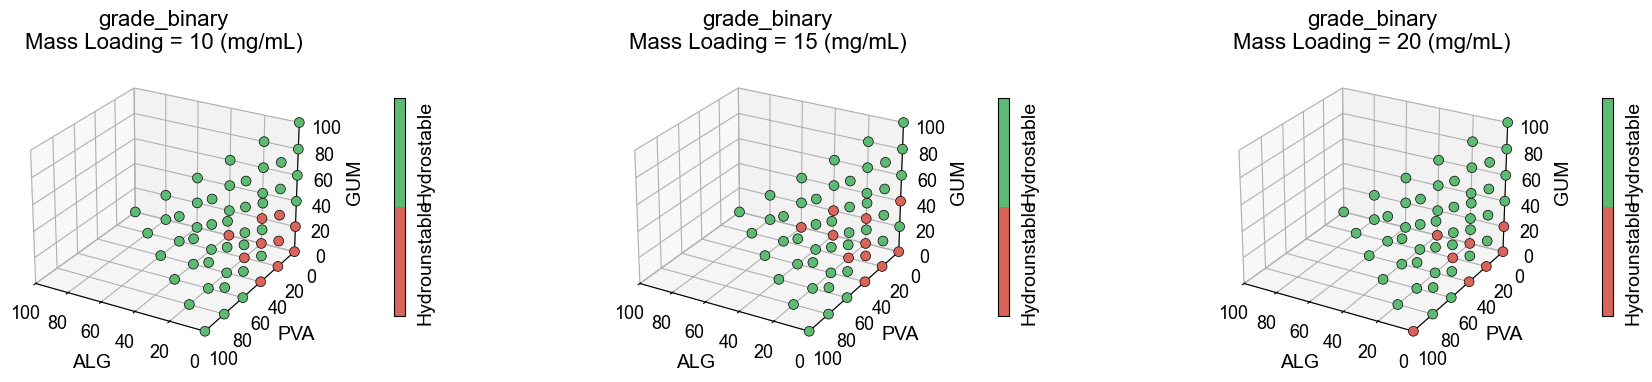

In [4]:
# Grade (binary: dissolved / solid)
cmap_grade = ListedColormap(['#d96459', '#5dba72'])
scatter_by_mass(mass_values, df, y_col='grade_binary',
                vmin=-0.5, vmax=1.5, s=50, label_pad=8, cmap=cmap_grade,
                cbar_label='', cbar_ticks=['Hydrounstable', 'Hydrostable'],
                edgecolor='black', linewidths=0.5, cbar_tick_position=[0, 1],
                cbar_shrink=0.5, figsize=FIGSIZE_3, cbar_pad=CBAR_PAD)
for ax in plt.gcf().axes:
    if hasattr(ax, 'zaxis'): ax.zaxis.labelpad = 5
    else: ax.tick_params(length=0, pad=8)
plt.gcf().subplots_adjust(**MARGINS)
plt.savefig(os.path.join(SAVE_FOLD, 'grade_raw.svg'), format='svg')
plt.show()

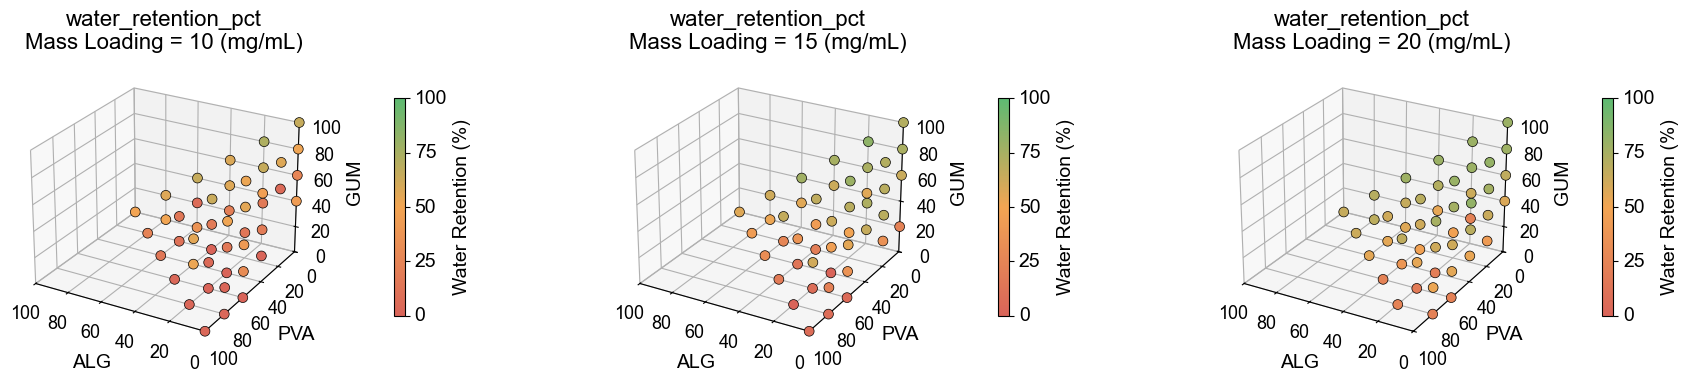

In [4]:
# Water retention (%) — solid samples only (Dissolved/grade C removed)
cmap_cont = LinearSegmentedColormap.from_list('rwg', ['#d96459', '#f2a553', '#5dba72'], N=256)
df_solid['water_retention_pct'] = df_solid['water_retention'] * 100
scatter_by_mass(mass_values, df_solid, y_col='water_retention_pct',
                vmin=0, vmax=100, cmap=cmap_cont, label_pad=8,
                edgecolor='black', linewidths=0.5, cbar_label='Water Retention (%)',
                cbar_ticks=['0', '25', '50', '75', '100'],
                cbar_tick_position=[0, 25, 50, 75, 100], cbar_shrink=0.5,
                cbar_tick_label_rotation=0, figsize=FIGSIZE_3, cbar_pad=CBAR_PAD)
for ax in plt.gcf().axes:
    if hasattr(ax, 'zaxis'): ax.zaxis.labelpad = 5
plt.gcf().subplots_adjust(**MARGINS)
plt.savefig(os.path.join(SAVE_FOLD, 'water_retention_raw.svg'), format='svg')
plt.show()

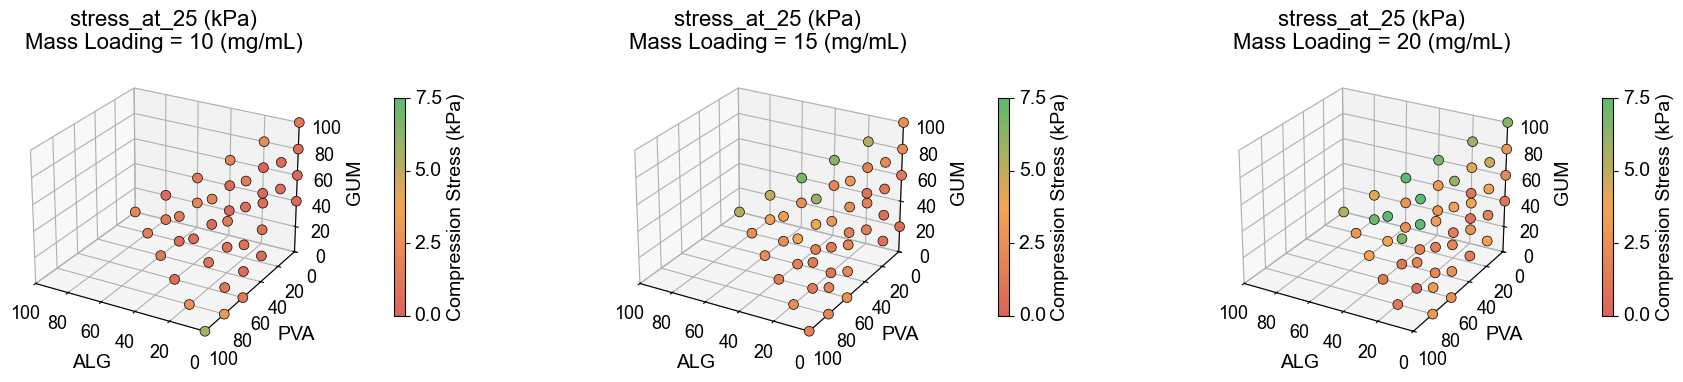

In [5]:
# Compression stress (kPa)
scatter_by_mass(mass_values, df_stress, y_col='stress_at_25 (kPa)',
                vmin=0, vmax=7.5, cmap=cmap_cont, label_pad=8,
                edgecolor='black', linewidths=0.5, cbar_label='Compression Stress (kPa)',
                cbar_ticks=[0.0, 2.5, 5.0, 7.5], cbar_tick_position=[0, 2.5, 5, 7.5],
                cbar_tick_label_rotation=0, cbar_shrink=0.5, figsize=FIGSIZE_3, cbar_pad=CBAR_PAD)
for ax in plt.gcf().axes:
    if hasattr(ax, 'zaxis'): ax.zaxis.labelpad = 5
plt.gcf().subplots_adjust(**MARGINS)
plt.savefig(os.path.join(SAVE_FOLD, 'stress_raw.svg'), format='svg')
plt.show()

## Grid, models, predictions

In [6]:
# Publication-resolution simplex grid (n_points=201)
df_grid = create_material_design_space(
    n_materials=4, n_points=201,
    material_names=['GUM', 'ALG', 'PVA', 'CMC'], mass_loadings=[10, 15, 20])
print(f'Grid size: {len(df_grid):,} rows')

Grid size: 4,120,857 rows


In [7]:
# Load pre-trained models from models/all_properties/ (+ OOF stress ensemble)
model_dir = 'models/all_properties'
svc_grade = joblib.load(f'{model_dir}/svc_grade.pkl')
scaler_grade = joblib.load(f'{model_dir}/scaler_grade.pkl')

svr_water = joblib.load(f'{model_dir}/svr_water.pkl')
scaler_water = joblib.load(f'{model_dir}/scaler_water.pkl')
target_scaler_water = joblib.load(f'{model_dir}/target_scaler_water.pkl')

ann_stress = PyTorchANNTrainer().load(f'{model_dir}/ann_stress.pt')
scaler_stress_ann = joblib.load(f'{model_dir}/scaler_stress_ann.pkl')
target_scaler_stress_ann = joblib.load(f'{model_dir}/target_scaler_stress_ann.pkl')

stress_bundle = load_stress_bundle('models/stress_ensemble_v2_seed10.pkl')
print('Models loaded.')

Models loaded.


In [8]:
X_grid = df_grid[FEATURE_COLS].values.copy()

# Grade (SVC): scale MassLoading only
X_grade = X_grid.copy()
X_grade[:, 4] = scaler_grade.transform(X_grade[:, 4].reshape(-1, 1)).ravel()
df_grid['grade_pred'] = svc_grade.predict(X_grade)

# Water (SVR): scale MassLoading only, inverse target, clip [0,1]
X_water = X_grid.copy()
X_water[:, 4] = scaler_water.transform(X_water[:, 4].reshape(-1, 1)).ravel()
df_grid['water_pred'] = np.clip(
    target_scaler_water.inverse_transform(svr_water.predict(X_water).reshape(-1, 1)).ravel(), 0, 1)

# Stress ANN (all 5 features scaled) — used for the pass/feasibility mask
X_stress_ann = scaler_stress_ann.transform(X_grid.copy())
df_grid['stress_ann_pred'] = target_scaler_stress_ann.inverse_transform(
    ann_stress.predict(X_stress_ann).reshape(-1, 1)).ravel()

# Stress OOF ensemble — the displayed stress prediction map
df_grid['stress_pred'] = predict_target_space(stress_bundle, df_grid[FEATURE_COLS])

print('Predictions complete.')
df_grid[['grade_pred', 'water_pred', 'stress_pred', 'stress_ann_pred']].describe()

Predictions complete.


,water_pred,stress_pred,stress_ann_pred
count,4.120857e+06,4.120857e+06,4.120857e+06
mean,4.216915e-01,2.111981e+00,1.706564e+00
std,2.239456e-01,1.331757e+00,1.251628e+00
min,0.000000e+00,-1.438304e-01,1.105365e-01
25%,2.410987e-01,1.205352e+00,7.114196e-01
50%,4.231831e-01,1.719860e+00,1.390450e+00
75%,6.061018e-01,2.789224e+00,2.338118e+00
max,8.355086e-01,7.274833e+00,6.213773e+00


## Prediction heatmaps

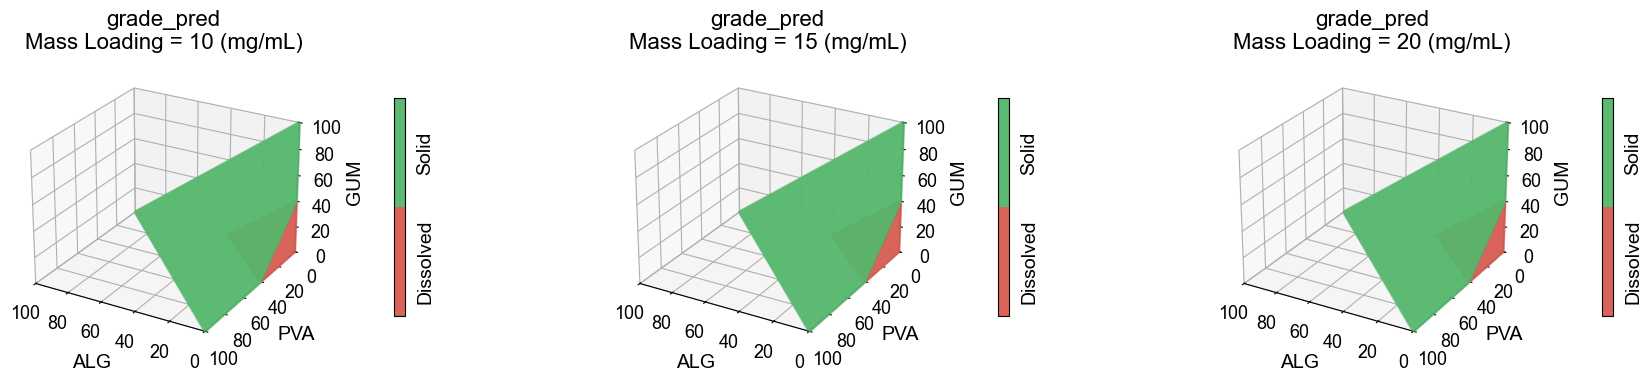

In [9]:
# Grade
cmap_grade_pred = ListedColormap(['#d96459', '#5dba72'])
scatter_by_mass(mass_values, df_grid, y_col='grade_pred',
                s=5, alpha=0.1, vmin=-0.5, vmax=1.5, cmap=cmap_grade_pred,
                cbar_label='', cbar_ticks=['Dissolved', 'Solid'], cbar_tick_position=[0, 1],
                cbar_shrink=0.5, figsize=FIGSIZE_3, rasterized=True, cbar_pad=CBAR_PAD)
for ax in plt.gcf().axes:
    if hasattr(ax, 'zaxis'): ax.zaxis.labelpad = 5
    else: ax.tick_params(length=0, pad=8)
plt.gcf().subplots_adjust(**MARGINS)
plt.savefig(os.path.join(SAVE_FOLD, 'grade_pred.svg'), format='svg', dpi=200)
plt.show()

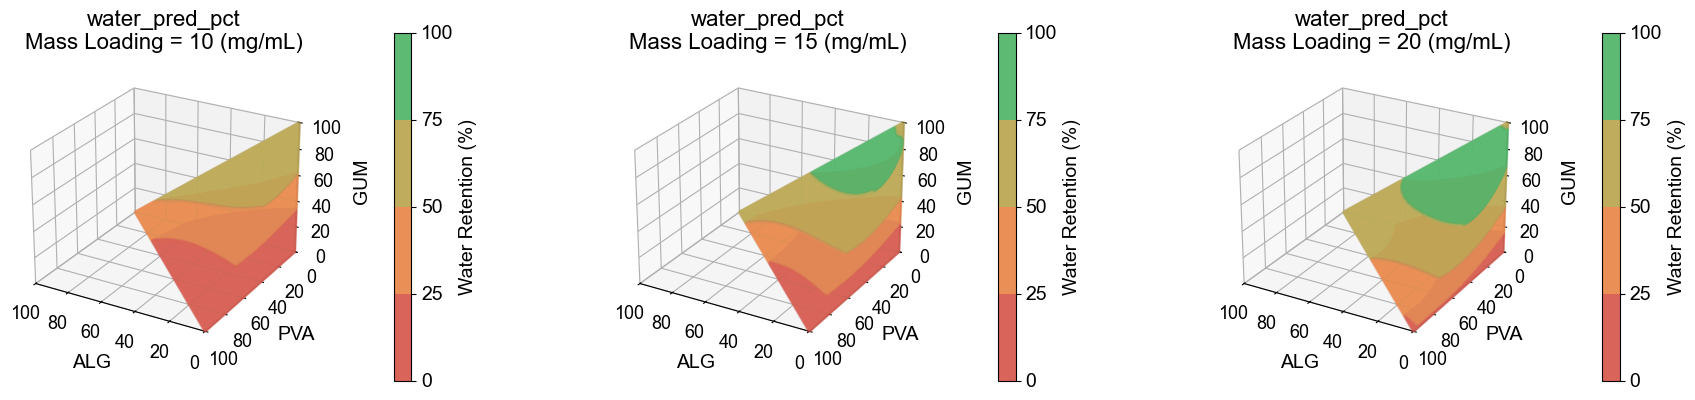

In [10]:
# Water retention
cmap_water = LinearSegmentedColormap.from_list('rwg', ['#d96459', '#f2a553', '#5dba72'], N=4)
df_grid['water_pred_pct'] = df_grid['water_pred'] * 100
scatter_by_mass(mass_values, df_grid, y_col='water_pred_pct',
                s=5, alpha=0.1, vmin=0, vmax=100, cmap=cmap_water,
                cbar_label='Water Retention (%)', cbar_ticks=['0', '25', '50', '75', '100'],
                cbar_tick_position=[0, 25, 50, 75, 100], cbar_tick_label_rotation=0,
                figsize=FIGSIZE_3, rasterized=True, cbar_pad=CBAR_PAD)
plt.gcf().subplots_adjust(**MARGINS)
plt.savefig(os.path.join(SAVE_FOLD, 'water_retention_pred.svg'), format='svg', dpi=200)
plt.show()

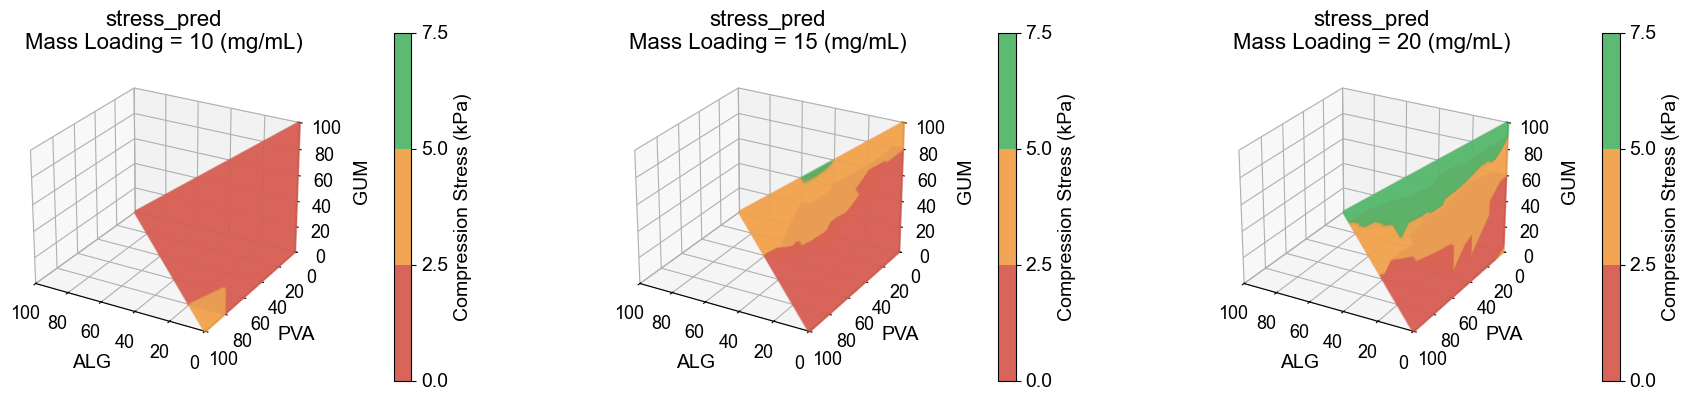

In [11]:
# Compression stress (OOF ensemble)
cmap_stress = LinearSegmentedColormap.from_list('rwg', ['#d96459', '#f2a553', '#5dba72'], N=3)
scatter_by_mass(mass_values, df_grid, y_col='stress_pred',
                s=5, alpha=0.1, vmin=0, vmax=7.5, cmap=cmap_stress,
                cbar_label='Compression Stress (kPa)', cbar_ticks=['0.0', '2.5', '5.0', '7.5'],
                cbar_tick_position=[0, 2.5, 5.0, 7.5], cbar_tick_label_rotation=0,
                figsize=FIGSIZE_3, rasterized=True, cbar_pad=CBAR_PAD)
plt.gcf().subplots_adjust(**MARGINS)
plt.savefig(os.path.join(SAVE_FOLD, 'stress_pred.svg'), format='svg', dpi=200)
plt.show()

## Combined feasibility (all properties pass)

> **Note — MassLoading = 10 excluded.** Its all-pass ratio is too low (≈ 3.5 % of compositions), so MassLoading = 10 is excluded completely from the feasible design space — its passing compositions are dropped from the feasible count, with the full grid kept as the denominator. This lowers the overall all-pass fraction from **33.9 % → 32.8 %**. The MassLoading = 10 panel is still shown in the feasibility heat map below for reference.

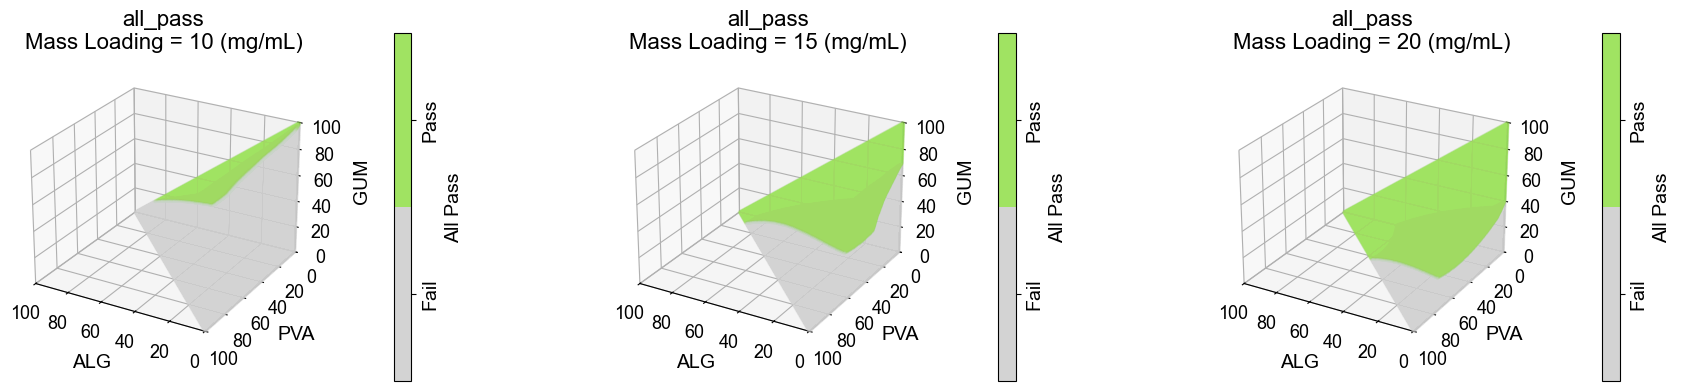

All-pass, full grid              : 1,398,112 / 4,120,857 (33.9%)
All-pass, MassLoading=10 excluded : 1,350,053 / 4,120,857 (32.8%)
  MassLoading=10: 48,059 / 1,373,619  (excluded)
  MassLoading=15: 475,237 / 1,373,619
  MassLoading=20: 874,816 / 1,373,619


In [12]:
# Per-target pass masks (grade solid, water >= 50%, ANN stress >= 1.0 kPa)
df_grid['grade_pass'] = (df_grid['grade_pred'] == True).astype(int)
df_grid['water_pass'] = (df_grid['water_pred'] >= 0.50).astype(int)
df_grid['stress_pass'] = (df_grid['stress_ann_pred'] >= 1.0).astype(int)
df_grid['all_pass'] = (df_grid['grade_pass'] & df_grid['water_pass'] & df_grid['stress_pass']).astype(int)

cmap_combined = ListedColormap(['lightgray', '#a0e362'])
scatter_by_mass(mass_values, df_grid, y_col='all_pass',
                s=5, alpha=0.1, vmin=-0.5, vmax=1.5, cmap=cmap_combined,
                cbar_label='All Pass', cbar_ticks=['Fail', 'Pass'], cbar_tick_position=[0, 1],
                figsize=FIGSIZE_3, rasterized=True, cbar_pad=CBAR_PAD)
plt.gcf().subplots_adjust(**MARGINS)
plt.savefig(os.path.join(SAVE_FOLD, 'all_pass.svg'), format='svg', dpi=200)
plt.show()

# MassLoading=10 is excluded from the feasible design space (its all-pass ratio is
# too low): drop its passes from the numerator, keeping the full grid as denominator.
# The MassLoading=10 panel is still plotted above for reference.
EXCLUDED_MASS = 10
n_total = len(df_grid)
n_full = df_grid['all_pass'].sum()
n_excl = df_grid.loc[df_grid['MassLoading'] != EXCLUDED_MASS, 'all_pass'].sum()
print(f'All-pass, full grid              : {n_full:,} / {n_total:,} ({n_full / n_total * 100:.1f}%)')
print(f'All-pass, MassLoading={EXCLUDED_MASS} excluded : {n_excl:,} / {n_total:,} ({n_excl / n_total * 100:.1f}%)')
for mass in mass_values:
    sub = df_grid[df_grid['MassLoading'] == mass]
    tag = '  (excluded)' if mass == EXCLUDED_MASS else ''
    print(f'  MassLoading={mass}: {sub["all_pass"].sum():,} / {len(sub):,}{tag}')